# Arthur — Objectif 1 : Fusion, Nettoyage & Modèle
Régression Linéaire vs Random Forest sur les données 2024 + 2025.

In [4]:
pip install pandas numpy matplotlib scikit-learn


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, sys
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, os.path.dirname(os.getcwd()))
import config
print(' config.py chargé')

 config.py chargé


## 1. Fusion des CSV

In [6]:
df24 = pd.read_csv(config.CSV_2024)
df25 = pd.read_csv(config.CSV_2025)
df   = pd.concat([df24, df25], ignore_index=True)
print(f'Total brut : {len(df)} lignes')

Total brut : 64103 lignes


## 2. Nettoyage

In [7]:
# Garder uniquement Maison et Appartement
df = df[df[config.COL_TYPE].isin(config.TYPES_BIENS)].copy()

# Supprimer doublons
df = df.drop_duplicates(subset='id_mutation')

# Supprimer lignes sans prix ou sans surface
df = df.dropna(subset=[config.COL_PRIX, config.COL_SURFACE, config.COL_PIECES])

# Colonnes date
df['date_mutation'] = pd.to_datetime(df[config.COL_DATE])
df['annee']         = df['date_mutation'].dt.year
df['mois']          = df['date_mutation'].dt.month

# Prix au m²
df['prix_m2'] = df[config.COL_PRIX] / df[config.COL_SURFACE]

# Supprimer aberrants
df = df[(df['prix_m2'] > 200) & (df['prix_m2'] < 15000)]
df = df[df[config.COL_SURFACE] < 1000]
df = df[df[config.COL_PRIX] > 5000]

# Encoder type_local (Maison=1, Appartement=0)
le = LabelEncoder()
df['type_encode'] = le.fit_transform(df[config.COL_TYPE])

print(f' {len(df)} lignes après nettoyage')
print(df[config.COL_TYPE].value_counts())

# Export data_clean.csv pour les autres
df.to_csv(config.DATA_CLEAN, index=False)
print(f'data_clean.csv exporté')

 9330 lignes après nettoyage
type_local
Maison         6874
Appartement    2456
Name: count, dtype: int64
data_clean.csv exporté


## 3. Préparation des features

In [8]:
FEATURES = [
    config.COL_SURFACE,
    config.COL_PIECES,
    config.COL_TERRAIN,
    config.COL_LAT,
    config.COL_LON,
    'type_encode',
    'annee',
    'mois',
]

X = df[FEATURES].fillna(0)
y = df[config.COL_PRIX]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train : {len(X_train)} | Test : {len(X_test)}')

Train : 7464 | Test : 1866


## 4. Régression Linéaire

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print('=== Régression Linéaire ===')
print(f'R²   : {r2_lr:.4f}')
print(f'MAE  : {mae_lr:,.0f} €')
print(f'RMSE : {rmse_lr:,.0f} €')

=== Régression Linéaire ===
R²   : 0.3858
MAE  : 66,457 €
RMSE : 99,840 €


## 5. Random Forest

In [10]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf  = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('=== Random Forest ===')
print(f'R²   : {r2_rf:.4f}')
print(f'MAE  : {mae_rf:,.0f} €')
print(f'RMSE : {rmse_rf:,.0f} €')

=== Random Forest ===
R²   : 0.5893
MAE  : 51,916 €
RMSE : 81,641 €


## 6. Comparaison visuelle

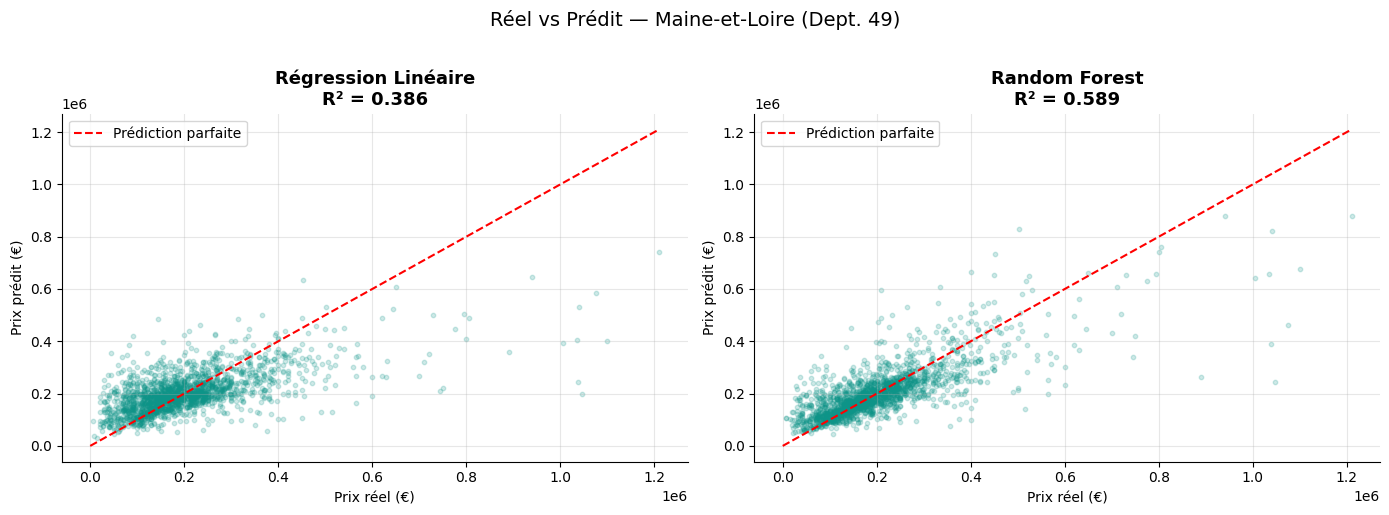

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titre, r2 in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Régression Linéaire', 'Random Forest'],
    [r2_lr, r2_rf]
):
    lim = max(y_test.max(), max(y_pred))
    ax.scatter(y_test, y_pred, alpha=0.2, s=10, color='#0D9488')
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Prédiction parfaite')
    ax.set_title(f'{titre}\nR² = {r2:.3f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prix réel (€)')
    ax.set_ylabel('Prix prédit (€)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Réel vs Prédit — Maine-et-Loire (Dept. 49)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.BASE_DIR, 'arthur_reel_vs_predit.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Importance des features (Random Forest)

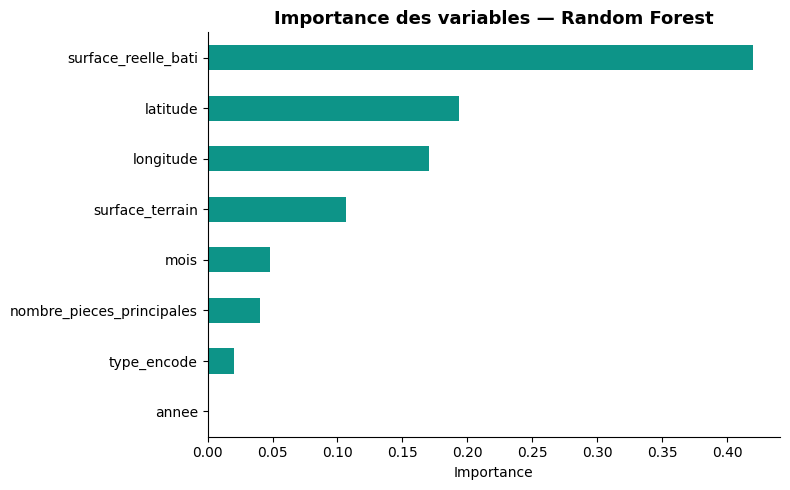

In [12]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#0D9488')
ax.set_title('Importance des variables — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(config.BASE_DIR, 'arthur_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Export du modèle

In [13]:
# On exporte le Random Forest (meilleur modèle)
with open(config.MODEL_OBJ1, 'wb') as f:
    pickle.dump(rf, f)

print(f' model_obj1.pkl exporté')
print(f'Features utilisées : {FEATURES}')
print(f'R² final (Random Forest) : {r2_rf:.4f}')

 model_obj1.pkl exporté
Features utilisées : ['surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'latitude', 'longitude', 'type_encode', 'annee', 'mois']
R² final (Random Forest) : 0.5893
